In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Red Wine Quality Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
data = pd.read_csv(url, sep=';')

# Create Binary Quality Target (1 = High Quality [>=6], 0 = Low Quality [<6])
data['quality_label'] = (data['quality'] >= 6).astype(int)

# Select Top Features (Alcohol & Volatile Acidity) or Full Feature Set
X = data[['alcohol', 'volatile acidity']]  # Or X = data.drop(['quality', 'quality_label'], axis=1)
y = data['quality_label']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (Crucial for Distance-Based Models like KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)

# Evaluate
y_pred = knn.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 72.81%

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.75      0.72       149
           1       0.77      0.71      0.74       171

    accuracy                           0.73       320
   macro avg       0.73      0.73      0.73       320
weighted avg       0.73      0.73      0.73       320



=== 5-FOLD CROSS-VALIDATION SUMMARY ===
Validation Accuracy: 74.05% (+/- 2.75%)
Validation ROC-AUC:  80.73%
Validation Precision:74.25%
Validation Recall:   73.62%
Validation F1-Score: 73.89%



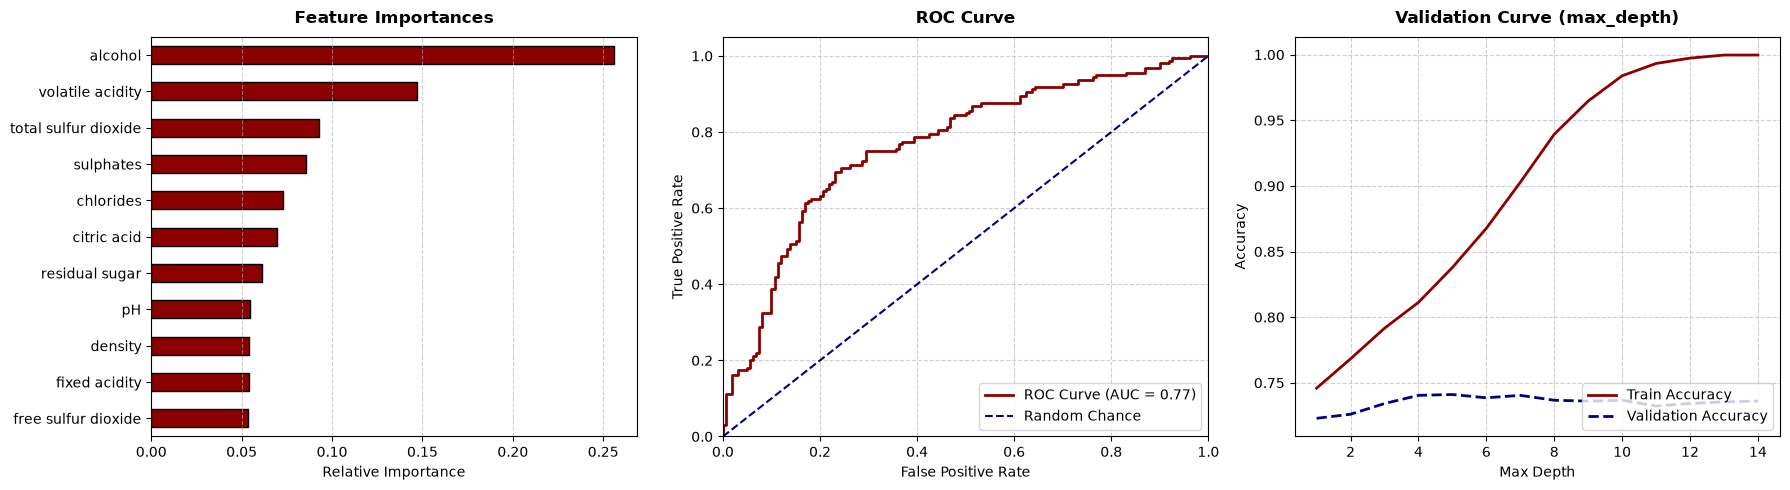

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# ==========================================
# 1. LOAD ORIGINAL UCI DATASET
# ==========================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# The original CSV uses semicolons ';' as delimiters
data = pd.read_csv(url, sep=';')

# Convert original 3-8 quality score into binary classification:
# 1 = Good Quality (Score >= 6)
# 0 = Low Quality  (Score < 6)
data['quality_label'] = (data['quality'] >= 6).astype(int)

# Separate features (X) and target (y), dropping original 'quality' column
X = data.drop(columns=['quality', 'quality_label'])
y = data['quality_label']

# ==========================================
# 2. MODEL TRAINING & SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

# Predict probabilities for ROC Curve
y_proba = rf.predict_proba(X_test)[:, 1]

# ==========================================
# 3. MODEL VALIDATION (5-FOLD CV)
# ==========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(rf, X, y, cv=cv, scoring=scoring, return_train_score=True)

print("=== 5-FOLD CROSS-VALIDATION SUMMARY (ORIGINAL DATA) ===")
print(f"Validation Accuracy: {cv_results['test_accuracy'].mean():.2%} (+/- {cv_results['test_accuracy'].std():.2%})")
print(f"Validation ROC-AUC:  {cv_results['test_roc_auc'].mean():.2%}")
print(f"Validation Precision:{cv_results['test_precision'].mean():.2%}")
print(f"Validation Recall:   {cv_results['test_recall'].mean():.2%}")
print(f"Validation F1-Score: {cv_results['test_f1'].mean():.2%}\n")

# ==========================================
# 4. VISUALIZATIONS (3-PANEL DASHBOARD)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Feature Importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[0], color='#8B0000', edgecolor='black')
axes[0].set_title('Feature Importances (Original Data)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Relative Importance')
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#8B0000', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Chance')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold', pad=10)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Validation Curve (Tuning max_depth)
param_range = np.arange(1, 15)
train_scores, test_scores = validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y, param_name="max_depth", param_range=param_range,
    cv=5, scoring="accuracy"
)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

axes[2].plot(param_range, train_mean, label="Train Accuracy", color='#8B0000', lw=2)
axes[2].plot(param_range, test_mean, label="Validation Accuracy", color="navy", lw=2, linestyle="--")
axes[2].set_xlabel("Max Depth")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Validation Curve (max_depth)", fontsize=12, fontweight='bold', pad=10)
axes[2].legend(loc="lower right")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Block A: Read input from frontend dir
import json
import os
import pandas as pd

input_file = os.path.abspath("../../frontend/public/data/input.json")
if os.path.exists(input_file):
    with open(input_file, "r") as f:
        input_data = json.load(f)
    print("Loaded input data:", input_data)
    input_df = pd.DataFrame([input_data.get("features", input_data)])
    display(input_df)
else:
    print(f"Input file not found at {input_file}. Creating sample input...")
    sample_features = {
        "fixed acidity": 8.31,
        "volatile acidity": 0.53,
        "citric acid": 0.27,
        "residual sugar": 2.54,
        "chlorides": 0.087,
        "free sulfur dioxide": 15.87,
        "total sulfur dioxide": 46.47,
        "density": 0.9967,
        "pH": 3.31,
        "sulphates": 0.66,
        "alcohol": 10.42
    }
    os.makedirs(os.path.dirname(input_file), exist_ok=True)
    with open(input_file, "w") as f:
        json.dump({"features": sample_features}, f, indent=2)
    input_df = pd.DataFrame([sample_features])
    print("Sample input created and loaded:")
    display(input_df)


In [ ]:
# Block B: Export predictions to frontend dir
import json
import os

output_file = os.path.abspath("../../frontend/public/data/output.json")
os.makedirs(os.path.dirname(output_file), exist_ok=True)

# Mock prediction output structure for validation phase
sample_output = {
    "quality": 1,
    "probability": 0.78,
    "message": "Prediction exported from test.ipynb"
}

with open(output_file, "w") as f:
    json.dump(sample_output, f, indent=2)

print(f"Exported prediction to {output_file}:")
print(json.dumps(sample_output, indent=2))
